# 06 · Dependence and copulas

Estimate dependence from matched company-years using the marginals from 05. Compare copulas, reinsurance and illustrative risk-adjusted returns. Results are in USD millions.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
require_results('multi_line_results.json')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats

from portfolio_model import (
    LINES, MIN_PREMIUM, load_and_clean_line, LineFit, MultiLineResults,
    marginal_from_fit, marginal_alternatives, independent_portfolio,
)
from risk_measures import var, es, var_diversification, k_diversification, euler_es_allocation
from dependence_model import (
    latent_from_spearman, latent_from_kendall, valid_correlation, gaussian_copula_uniforms,
    t_copula_uniforms, comonotonic_uniforms, portfolio_from_uniforms,
    empirical_coexceedance, gaussian_coexceedance, t_coexceedance,
)
from reinsurance_model import quota_share, aggregate_xol

nb05 = MultiLineResults.from_json(result_path('multi_line_results.json'))
fits = {line: LineFit(**nb05.fits[line]) for line in LINES}
N_SIM = nb05.n_sim
M = 1000.0                                   # data are USD thousands; results are shown in USD millions
USDM = lambda v: f'USD {v / M:,.1f}m'

print(f"Loaded from notebook 05 (USD thousands -> millions): sum of stand-alone VaR99.5 = {USDM(nb05.sum_standalone_var995)}, "
      f"independence portfolio VaR99.5 = {USDM(nb05.portfolio_var995)}, "
      f"D_VaR = {nb05.d_var:.1%}, D_K = {nb05.d_k:.1%}")

Loaded from notebook 05 (USD thousands -> millions): sum of stand-alone VaR99.5 = USD 96.1m, independence portfolio VaR99.5 = USD 60.3m, D_VaR = 37.3%, D_K = 52.8%


## Matched rank correlations

Spearman correlation on matched company-year pairs. Pairs with fewer than 100 matches get a correlation of 0. That is a data gap, not evidence of independence.

In [2]:
MIN_MATCHED = 100
cleaned_full = {}
for line in LINES:
    cred, _ = load_and_clean_line(line, data_dir=DATA_DIR, min_premium=MIN_PREMIUM)
    cleaned_full[line] = cred[['GRCODE', 'AccidentYear', 'LossRatio']].rename(columns={'LossRatio': line})

pair_rows = []
corr = pd.DataFrame(np.eye(len(LINES)), index=LINES, columns=LINES)      # Spearman
tau_m = pd.DataFrame(np.eye(len(LINES)), index=LINES, columns=LINES)     # Kendall
for a, b in combinations(LINES, 2):
    merged = pd.merge(cleaned_full[a], cleaned_full[b], on=['GRCODE', 'AccidentYear'], how='inner')
    n = len(merged)
    if n >= MIN_MATCHED:
        rho, _ = stats.spearmanr(merged[a], merged[b])
        tau, _ = stats.kendalltau(merged[a], merged[b])
    else:
        rho = tau = 0.0
    corr.loc[a, b] = corr.loc[b, a] = rho
    tau_m.loc[a, b] = tau_m.loc[b, a] = tau
    pair_rows.append(dict(pair=f'{a}-{b}', n_matched=n, n_companies=merged['GRCODE'].nunique() if n else 0,
                           rho_spearman=rho, tau_kendall=tau, used=n >= MIN_MATCHED))

pair_table = pd.DataFrame(pair_rows)
pair_table.round(3)

,pair,n_matched,n_companies,rho_spearman,tau_kendall,used
0,ppauto-comauto,387,52,0.205,0.144,True
1,ppauto-wkcomp,183,32,0.187,0.137,True
2,ppauto-othliab,320,39,0.080,0.053,True
3,ppauto-medmal,2,1,0.000,0.000,False
4,ppauto-prodliab,46,7,0.000,0.000,False
5,comauto-wkcomp,306,42,0.295,0.204,True
6,comauto-othliab,440,58,0.193,0.131,True
7,comauto-medmal,2,1,0.000,0.000,False
8,comauto-prodliab,58,9,0.000,0.000,False
9,wkcomp-othliab,258,43,-0.017,-0.012,True


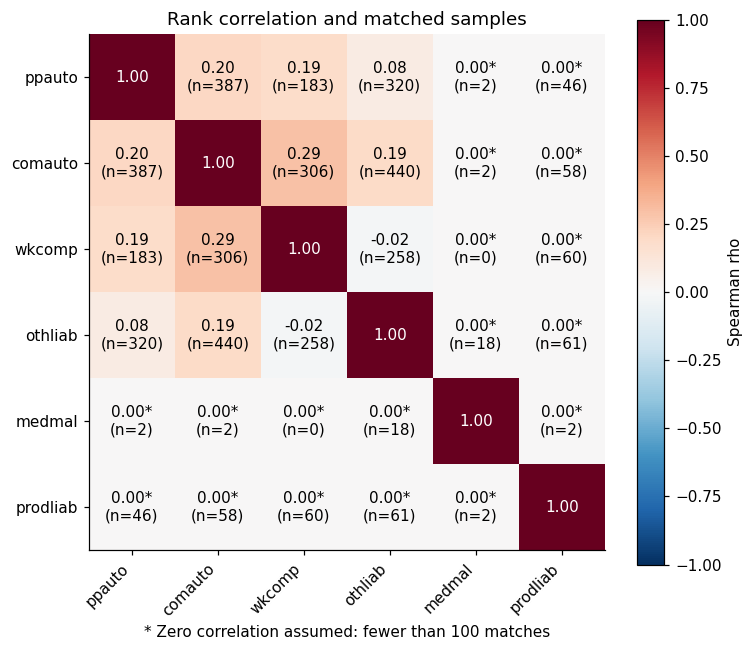

Eigenvalues: [0.6404 0.8333 1.     1.     1.0188 1.5075]  -- positive semi-definite: True
medmal and prodliab: fewer than 100 matched company-years with every other line -> correlation set to 0, an explicit data-availability limitation, not a claim of true independence.


In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(LINES))); ax.set_xticklabels(LINES, rotation=45, ha='right')
ax.set_yticks(range(len(LINES))); ax.set_yticklabels(LINES)
for i in range(len(LINES)):
    for j in range(len(LINES)):
        n_ij = int(pair_table.loc[(pair_table['pair']==f'{LINES[i]}-{LINES[j]}') | (pair_table['pair']==f'{LINES[j]}-{LINES[i]}'), 'n_matched'].sum()) if i != j else nb05.fits[LINES[i]]['n_fit']
        label = '1.00' if i == j else f'{corr.values[i,j]:.2f}{"*" if n_ij < MIN_MATCHED else ""}\n(n={n_ij})'
        ax.text(j, i, label, ha='center', va='center', color='white' if i==j else 'black')
plt.colorbar(im, label='Spearman rho')
ax.set_title('Rank correlation and matched samples')
ax.grid(False)
ax.set_xlabel('* Zero correlation assumed: fewer than 100 matches')
plt.tight_layout(); plt.show()

eigvals = np.linalg.eigvalsh(corr.values)
print(f"Eigenvalues: {eigvals.round(4)}  -- positive semi-definite: {np.all(eigvals >= -1e-8)}")
print("medmal and prodliab: fewer than 100 matched company-years with every other line -> correlation set to 0,"
      " an explicit data-availability limitation, not a claim of true independence.")

## Year and company effects

Raw correlations next to correlations after removing year or company means. This is descriptive only and doesn't identify causes.

In [4]:
decomp_rows = []
for a, b in combinations(LINES, 2):
    merged = pd.merge(cleaned_full[a], cleaned_full[b], on=['GRCODE', 'AccidentYear'], how='inner')
    if len(merged) < MIN_MATCHED:
        continue
    rho_raw, _ = stats.spearmanr(merged[a], merged[b])
    a_yr = merged[a] - merged.groupby('AccidentYear')[a].transform('mean')
    b_yr = merged[b] - merged.groupby('AccidentYear')[b].transform('mean')
    rho_year_resid, _ = stats.spearmanr(a_yr, b_yr)
    a_co = merged[a] - merged.groupby('GRCODE')[a].transform('mean')
    b_co = merged[b] - merged.groupby('GRCODE')[b].transform('mean')
    rho_co_resid, _ = stats.spearmanr(a_co, b_co)
    decomp_rows.append(dict(pair=f'{a}-{b}', n=len(merged), rho_raw=rho_raw,
                             rho_after_removing_year_effect=rho_year_resid,
                             rho_after_removing_company_effect=rho_co_resid))

decomp_table = pd.DataFrame(decomp_rows)
decomp_table.round(3)

,pair,n,rho_raw,rho_after_removing_year_effect,rho_after_removing_company_effect
0,ppauto-comauto,387,0.205,0.138,0.321
1,ppauto-wkcomp,183,0.187,0.174,0.175
2,ppauto-othliab,320,0.080,0.068,0.203
3,comauto-wkcomp,306,0.295,0.238,0.171
4,comauto-othliab,440,0.193,0.165,0.177
5,wkcomp-othliab,258,-0.017,0.046,0.080


Removing year or company means changes ppauto–comauto correlation from 0.205 to 0.138 or 0.321. Residual correlations remain positive for the pairs shown. These comparisons describe co-movement without identifying its causes.

## Upper-quadrant co-exceedance

Share of matched company-years in which both lines are above their own q-quantile, from within-pair ranks. This is a moderate upper-tail diagnostic (q = 0.80 and 0.90), not evidence about the extreme tail: at q = 0.90 each pair has only a handful of joint observations, so the counts are shown next to the rates. The comparison values use the parameterisation of each copula: Gaussian with latent correlation 2 sin(π ρ_S / 6), Student-t (5 dof) with latent correlation sin(π τ / 2).

In [5]:
Q_LEVELS = [0.80, 0.90]
coexceed_rows = []
for a, b in combinations(LINES, 2):
    merged = pd.merge(cleaned_full[a], cleaned_full[b], on=['GRCODE', 'AccidentYear'], how='inner')
    n = len(merged)
    if n < MIN_MATCHED:
        continue
    rho_s, _ = stats.spearmanr(merged[a], merged[b])
    tau, _ = stats.kendalltau(merged[a], merged[b])
    r_gauss, r_t = 2 * np.sin(np.pi * rho_s / 6), np.sin(np.pi * tau / 2)
    for q in Q_LEVELS:
        emp, joint = empirical_coexceedance(merged[a].to_numpy(), merged[b].to_numpy(), q)
        coexceed_rows.append(dict(pair=f'{a}-{b}', q=q, n=n, joint_count=joint, expected_count_independence=n * (1 - q) ** 2,
                                   empirical=emp, gaussian_implied=gaussian_coexceedance(r_gauss, q),
                                   t5_implied=t_coexceedance(r_t, 5, q), independence=(1 - q) ** 2))

coexceed_table = pd.DataFrame(coexceed_rows)
display(coexceed_table.round(4))
few = coexceed_table[(coexceed_table.q == 0.90) & (coexceed_table.joint_count < 10)]
print(f'At q = 0.90, {len(few)} of {int((coexceed_table.q == 0.90).sum())} pairs have fewer than 10 joint exceedances '
      f'(maximum {int(coexceed_table.loc[coexceed_table.q == 0.90, "joint_count"].max())}). q = 0.95 and 0.99 are not attempted.')

,pair,q,n,joint_count,expected_count_independence,empirical,gaussian_implied,t5_implied,independence
0,ppauto-comauto,0.800,387,23,15.480,0.059,0.058,0.064,0.040
1,ppauto-comauto,0.900,387,6,3.870,0.015,0.018,0.024,0.010
2,ppauto-wkcomp,0.800,183,11,7.320,0.060,0.056,0.063,0.040
3,ppauto-wkcomp,0.900,183,6,1.830,0.033,0.017,0.023,0.010
4,ppauto-othliab,0.800,320,24,12.800,0.075,0.047,0.052,0.040
5,ppauto-othliab,0.900,320,11,3.200,0.034,0.013,0.018,0.010
6,comauto-wkcomp,0.800,306,26,12.240,0.085,0.067,0.072,0.040
7,comauto-wkcomp,0.900,306,11,3.060,0.036,0.022,0.028,0.010
8,comauto-othliab,0.800,440,32,17.600,0.073,0.057,0.062,0.040
9,comauto-othliab,0.900,440,12,4.400,0.027,0.017,0.023,0.010


At q = 0.90, 3 of 6 pairs have fewer than 10 joint exceedances (maximum 12). q = 0.95 and 0.99 are not attempted.


Empirical co-exceedance exceeds the Gaussian value for all six pairs at q = 0.80 and five pairs at q = 0.90. Student-t values are closer to the observed rates. Joint counts are small: 11–32 and 4–12 respectively. Repeated company observations also limit inference about tail dependence.

## Copula scenarios

Two latent correlation matrices are built from the same matched data: a Gaussian one from Spearman's rho, 2 sin(π ρ_S / 6), and a Student-t one from Kendall's tau, sin(π τ / 2) (exact for elliptical copulas). Both are checked for positive definiteness; if one failed, it would be replaced by the nearest correlation matrix (Higham) and the change reported. Pairs with fewer than 100 matches get zero in both. Student-t degrees of freedom are assumptions. Independence and comonotonic are reference cases. D_VaR and D_K use the stand-alone VaR and mean of the independence simulation in every row, so only the dependence changes.

In [6]:
R_gauss, rep_gauss = valid_correlation(latent_from_spearman(corr.to_numpy()))
R_t, rep_t = valid_correlation(latent_from_kendall(tau_m.to_numpy()))
print('Gaussian latent (from Spearman):', rep_gauss)
print('Student-t latent (from Kendall):', rep_t)
print(f'Largest absolute difference between the two latent matrices: {np.abs(R_gauss - R_t).max():.4f}')
latent_corr = R_gauss                      # kept under this name for the stress path below

marginals = {line: marginal_from_fit(fits[line]) for line in LINES}
base_ind = independent_portfolio(fits, N_SIM, seed_base=1000)
sa_var_ref = np.array([var(base_ind.per_line[l], 0.995) for l in LINES])
sa_mean_ref = np.array([base_ind.per_line[l].mean() for l in LINES])
assert np.isclose(var(base_ind.total, 0.995), nb05.portfolio_var995), 'independence baseline differs from notebook 05'

def scenario_row(name, total):
    v = var(total, 0.995)
    return dict(scenario=name, VaR995=v / M, ES995=es(total, 0.995) / M, K=(v - sa_mean_ref.sum()) / M,
                D_VaR=var_diversification(v, sa_var_ref), D_K=k_diversification(v, sa_mean_ref.sum(), sa_var_ref, sa_mean_ref))

scenarios = [scenario_row('Independence benchmark (notebook 05)', base_ind.total)]
gauss_per_line, gauss_total = portfolio_from_uniforms(marginals, gaussian_copula_uniforms(R_gauss, N_SIM, seed=42))
scenarios.append(scenario_row('Gaussian copula (Spearman -> latent)', gauss_total))
for dof in [3, 5, 10, 30]:
    _, t_total = portfolio_from_uniforms(marginals, t_copula_uniforms(R_t, dof, N_SIM, seed=42))
    scenarios.append(scenario_row(f'Student-t copula, dof={dof} (Kendall -> latent)', t_total))
_, como_total = portfolio_from_uniforms(marginals, comonotonic_uniforms(len(LINES), N_SIM, seed=42))
scenarios.append(scenario_row('Comonotonic (perfect positive dependence)', como_total))

scenario_table = pd.DataFrame(scenarios)
print('USD millions; D_VaR = 1 - VaR/sum VaR_i, D_K = 1 - K/sum K_i with K = VaR - E[loss]')
scenario_table.round(3)

Gaussian latent (from Spearman): {'min_eigenvalue': 0.6246208768128932, 'corrected': False, 'frobenius_change': 0.0}
Student-t latent (from Kendall): {'min_eigenvalue': 0.616307678977744, 'corrected': False, 'frobenius_change': 0.0}
Largest absolute difference between the two latent matrices: 0.0183


USD millions; D_VaR = 1 - VaR/sum VaR_i, D_K = 1 - K/sum K_i with K = VaR - E[loss]


,scenario,VaR995,ES995,K,D_VaR,D_K
0,Independence benchmark (notebook 05),60.304,79.653,32.034,0.373,0.528
1,Gaussian copula (Spearman -> latent),62.202,82.740,33.932,0.353,0.500
2,"Student-t copula, dof=3 (Kendall -> latent)",68.610,94.417,40.340,0.286,0.406
3,"Student-t copula, dof=5 (Kendall -> latent)",66.829,88.990,38.559,0.305,0.432
4,"Student-t copula, dof=10 (Kendall -> latent)",64.792,86.084,36.522,0.326,0.462
5,"Student-t copula, dof=30 (Kendall -> latent)",62.842,82.630,34.572,0.346,0.491
6,Comonotonic (perfect positive dependence),96.110,127.222,67.840,0.000,0.001


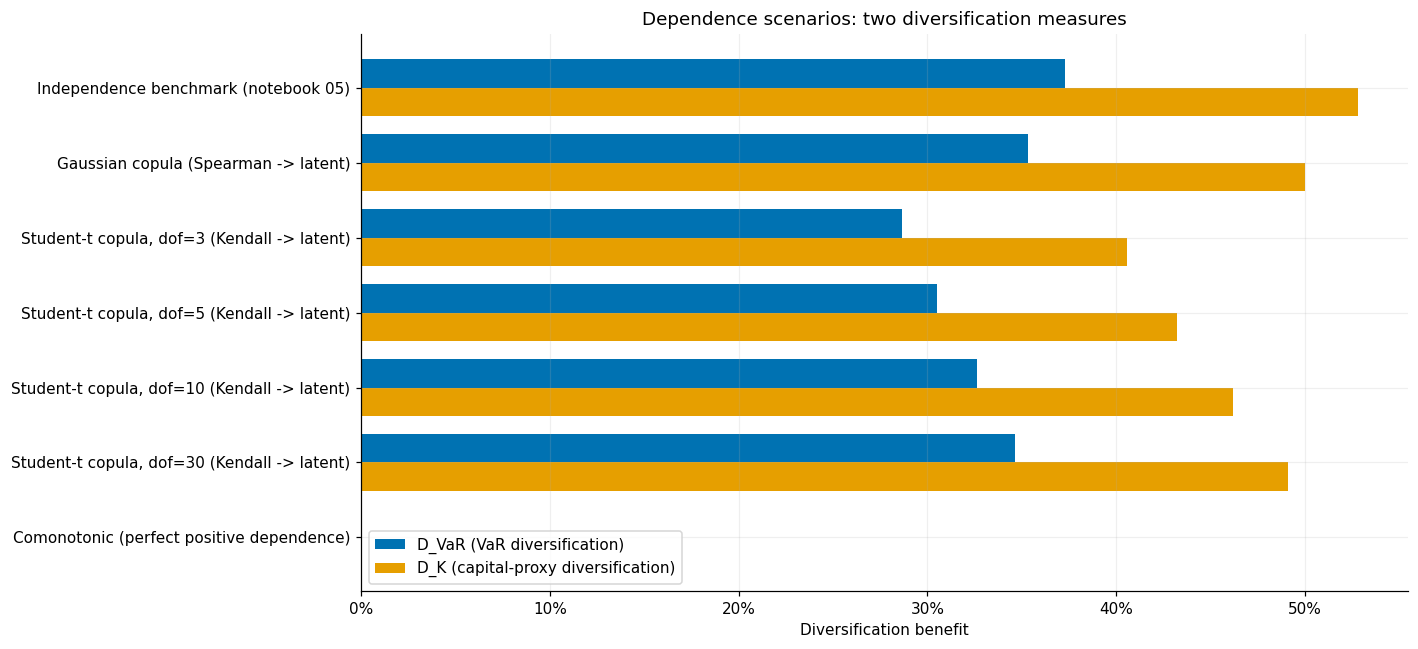

In [7]:
from matplotlib.ticker import PercentFormatter
fig, ax = plt.subplots(figsize=(13, 6))
y = np.arange(len(scenario_table)); h = 0.38
ax.barh(y - h/2, scenario_table['D_VaR'], height=h, color='C0', label='D_VaR (VaR diversification)')
ax.barh(y + h/2, scenario_table['D_K'], height=h, color='C1', label='D_K (capital-proxy diversification)')
ax.set_yticks(y); ax.set_yticklabels(scenario_table['scenario']); ax.invert_yaxis()
ax.set_xlabel('Diversification benefit'); ax.set_title('Dependence scenarios: two diversification measures')
ax.legend()
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout(); plt.show()

Portfolio VaR 99.5% runs from USD 60.3m (independence benchmark) through 62.2m (Gaussian copula) and 66.8m (Student-t, 5 dof) to 96.1m (comonotonic). Both latent matrices are positive definite, so no nearest-correlation correction was applied; they differ by at most 0.018. D_VaR falls from 37.3% to 35.3% (Gaussian), 30.5% (t, 5 dof) and 0% (comonotonic). D_K is larger in every row (52.8%, 50.0%, 43.2%, 0.1%) because expected losses are netted off on both sides and do not diversify. Independence and comonotonic are reference cases, not bounds: negative dependence would diversify more than independence, and the estimated dependence here is weakly positive.

## Correlation stress

Move the latent matrix toward an off-diagonal correlation of 0.7. The path is assumed, not estimated, so it has no confidence interval.

In [8]:
high_dep = np.full((len(LINES), len(LINES)), 0.7)
np.fill_diagonal(high_dep, 1.0)

stress_rows = []
for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    R = (1 - alpha) * latent_corr + alpha * high_dep
    _, total = portfolio_from_uniforms(marginals, gaussian_copula_uniforms(R, N_SIM, seed=42))
    row = scenario_row(f'alpha={alpha}', total); row['alpha'] = alpha
    stress_rows.append(row)

stress_table = pd.DataFrame(stress_rows).drop(columns='scenario').set_index('alpha').reset_index()
stress_table.round(3)

,alpha,VaR995,ES995,K,D_VaR,D_K
0,0.000,62.202,82.740,33.932,0.353,0.500
1,0.250,67.339,88.492,39.069,0.300,0.424
2,0.500,72.870,94.982,44.600,0.242,0.343
3,0.750,78.876,102.462,50.606,0.180,0.254
4,1.000,85.307,111.086,57.037,0.113,0.160


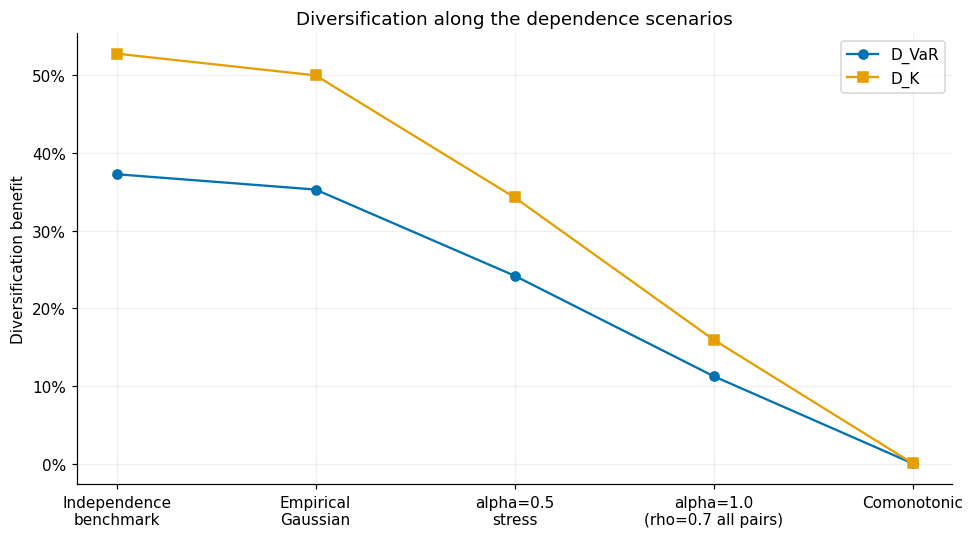

In [9]:
from matplotlib.ticker import PercentFormatter
fig, ax = plt.subplots(figsize=(9, 5))
x_labels = ['Independence\nbenchmark', 'Empirical\nGaussian', 'alpha=0.5\nstress', 'alpha=1.0\n(rho=0.7 all pairs)', 'Comonotonic']
pick = lambda df, col, key, val: df.loc[df[key] == val, col].iloc[0]
d_var_vals = [nb05.d_var, pick(scenario_table, 'D_VaR', 'scenario', 'Gaussian copula (Spearman -> latent)'),
              pick(stress_table, 'D_VaR', 'alpha', 0.5), pick(stress_table, 'D_VaR', 'alpha', 1.0), scenario_table['D_VaR'].iloc[-1]]
d_k_vals = [nb05.d_k, pick(scenario_table, 'D_K', 'scenario', 'Gaussian copula (Spearman -> latent)'),
            pick(stress_table, 'D_K', 'alpha', 0.5), pick(stress_table, 'D_K', 'alpha', 1.0), scenario_table['D_K'].iloc[-1]]
ax.plot(range(5), d_var_vals, 'o-', color='C0', label='D_VaR')
ax.plot(range(5), d_k_vals, 's-', color='C1', label='D_K')
ax.set_xticks(range(5)); ax.set_xticklabels(x_labels)
ax.set_ylabel('Diversification benefit'); ax.set_title('Diversification along the dependence scenarios'); ax.legend()
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout(); plt.show()

## ES allocation

Portfolio ES 99.5% allocated to each line by its mean loss in the tail scenarios. Contributions add up to total ES within tolerance.

In [10]:
v_total = var(gauss_total, 0.995)
alloc = euler_es_allocation(gauss_total, gauss_per_line, 0.995)
port_es = es(gauss_total, 0.995)
sum_alloc = sum(alloc.values())
assert np.isclose(sum_alloc, port_es), "Euler allocation must sum exactly to portfolio ES"

sum_premium = sum(fits[l].book_premium for l in LINES)
mean_total = {line: gauss_per_line[line].mean() for line in LINES}
sum_mean = sum(mean_total.values())

attribution = pd.DataFrame({
    'Line': LINES,
    'Premium share': [fits[l].book_premium / sum_premium for l in LINES],
    'Expected-loss share': [mean_total[l] / sum_mean for l in LINES],
    'Standalone VaR995 share': [nb05.standalone_var995[l] / nb05.sum_standalone_var995 for l in LINES],
    'Allocated ES995 share (Euler)': [alloc[l] / sum_alloc for l in LINES],
})
attribution.round(3)

,Line,Premium share,Expected-loss share,Standalone VaR995 share,Allocated ES995 share (Euler)
0,ppauto,0.285,0.279,0.150,0.115
1,comauto,0.136,0.117,0.082,0.059
2,wkcomp,0.276,0.299,0.404,0.691
3,othliab,0.098,0.082,0.094,0.035
4,medmal,0.117,0.149,0.173,0.071
5,prodliab,0.089,0.073,0.096,0.030


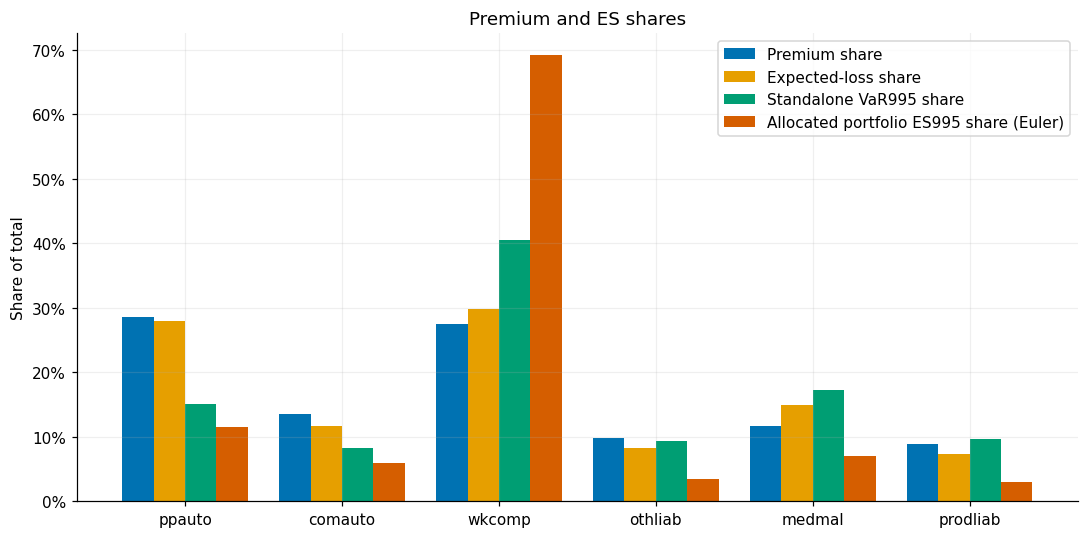

Workers' comp: 27.6% of premium, but 69.1% of allocated tail capital.


In [11]:
from matplotlib.ticker import PercentFormatter
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(LINES)); w = 0.2
ax.bar(x - 1.5*w, attribution['Premium share'], width=w, label='Premium share')
ax.bar(x - 0.5*w, attribution['Expected-loss share'], width=w, label='Expected-loss share')
ax.bar(x + 0.5*w, attribution['Standalone VaR995 share'], width=w, label='Standalone VaR995 share')
ax.bar(x + 1.5*w, attribution['Allocated ES995 share (Euler)'], width=w, label='Allocated portfolio ES995 share (Euler)')
ax.set_xticks(x); ax.set_xticklabels(LINES, rotation=0)
ax.set_ylabel('Share of total')
ax.set_title('Premium and ES shares')
ax.legend()
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout(); plt.show()

print(f"Workers' comp: {attribution.loc[attribution['Line']=='wkcomp','Premium share'].iloc[0]:.1%} of premium, "
      f"but {attribution.loc[attribution['Line']=='wkcomp','Allocated ES995 share (Euler)'].iloc[0]:.1%} of allocated tail capital.")

Workers' comp is 27.6% of premium but 69.1% of allocated ES under the Gaussian copula and the baseline marginals. Premium and expected-loss shares are far flatter. This describes the selected model, not a regulatory allocation; the marginal-model comparison below shows how much that share depends on the wkcomp marginal.

## Illustrative RORAC by line

RORAC is expected underwriting profit divided by allocated capital. Expenses are assumed at 30% of premium, with 25% and 35% sensitivities. Capital is Euler ES allocation minus expected loss; line premiums are the medians from 05. This measures returns for the assumed portfolio, not an observed insurer.

In [12]:
EXPENSE_RATIO = 0.30          # assumption: the CAS extract has no expense data
cap_alloc = {l: alloc[l] - mean_total[l] for l in LINES}
assert np.isclose(sum(cap_alloc.values()), port_es - sum_mean)

def rorac_table(expense_ratio):
    rows = []
    for l in LINES:
        premium = fits[l].book_premium
        profit = premium * (1 - expense_ratio) - mean_total[l]
        rows.append(dict(Line=l, premium=premium / M, expected_loss=mean_total[l] / M, expected_profit=profit / M,
                         allocated_capital=cap_alloc[l] / M, RORAC=profit / cap_alloc[l]))
    tot_profit = sum(fits[l].book_premium for l in LINES) * (1 - expense_ratio) - sum_mean
    rows.append(dict(Line='Portfolio', premium=sum_premium / M, expected_loss=sum_mean / M, expected_profit=tot_profit / M,
                     allocated_capital=sum(cap_alloc.values()) / M, RORAC=tot_profit / sum(cap_alloc.values())))
    return pd.DataFrame(rows)

rorac = rorac_table(EXPENSE_RATIO)
print(f'Illustrative RORAC, expense ratio {EXPENSE_RATIO:.0%} of premium (assumed), USD millions, Gaussian copula, ES 99.5% Euler capital')
display(rorac.round(3))
rorac_sens = pd.DataFrame({f'ER {er:.0%}': rorac_table(er).set_index('Line')['RORAC'] for er in (0.25, 0.30, 0.35)})
display(rorac_sens.round(3))

Illustrative RORAC, expense ratio 30% of premium (assumed), USD millions, Gaussian copula, ES 99.5% Euler capital


,Line,premium,expected_loss,expected_profit,allocated_capital,RORAC
0,ppauto,11.786,7.898,0.352,1.607,0.219
1,comauto,5.618,3.323,0.610,1.559,0.391
2,wkcomp,11.395,8.454,-0.478,48.730,-0.010
3,othliab,4.063,2.330,0.515,0.528,0.975
4,medmal,4.828,4.226,-0.846,1.620,-0.523
5,prodliab,3.668,2.060,0.507,0.406,1.250
6,Portfolio,41.358,28.291,0.659,54.449,0.012


,ER 25%,ER 30%,ER 35%
Line,,,
ppauto,0.586,0.219,-0.148
comauto,0.571,0.391,0.211
wkcomp,0.002,-0.010,-0.021
othliab,1.360,0.975,0.590
medmal,-0.374,-0.523,-0.672
prodliab,1.702,1.250,0.798
Portfolio,0.050,0.012,-0.026


At 30% expenses, expected profit is USD 0.7m on USD 54.4m of allocated capital, giving RORAC of 1.2%. Workers' compensation carries USD 48.7m of capital and RORAC near −1%. Medmal is −52%; othliab and prodliab are 98% and 125%, reflecting their small tail allocations. Rankings depend on expenses and marginal assumptions.

## Portfolio-level reinsurance

Apply treaties to the same joint line-loss draws before aggregation. Compare a 25% quota share with per-line stop-loss covering 200% of premium above a 100% attachment. Show both Gaussian dependence and independence. Retained losses exclude reinsurance premiums; D_K uses retained expected losses.

In [13]:
treaties = {
    'Quota share 25%':                lambda l, L: quota_share(L, 0.25),
    'Stop-loss 200% xs 100% premium': lambda l, L: aggregate_xol(L, attachment=fits[l].book_premium, limit=2 * fits[l].book_premium),
}

def reinsurance_view(per_line, label):
    rows = []
    gross_total = np.sum([per_line[l] for l in LINES], axis=0)
    g_var, g_es = var(gross_total, 0.995), es(gross_total, 0.995)
    g_sa_var = np.array([var(per_line[l], 0.995) for l in LINES]); g_sa_mean = np.array([per_line[l].mean() for l in LINES])
    rows.append(dict(dependence=label, treaty='Gross', VaR995=g_var / M, ES995=g_es / M, expected_ceded=0.0, VaR_relief=0.0, ES_relief=0.0,
                     D_VaR=var_diversification(g_var, g_sa_var), D_K=k_diversification(g_var, gross_total.mean(), g_sa_var, g_sa_mean)))
    for name, treaty in treaties.items():
        net, ceded = {}, {}
        for l in LINES:
            net[l], ceded[l] = treaty(l, per_line[l])
            np.testing.assert_allclose(net[l] + ceded[l], per_line[l], rtol=1e-12, atol=1e-8)
        net_total = np.sum([net[l] for l in LINES], axis=0)
        n_var, n_es = var(net_total, 0.995), es(net_total, 0.995)
        n_sa_var = np.array([var(net[l], 0.995) for l in LINES]); n_sa_mean = np.array([net[l].mean() for l in LINES])
        rows.append(dict(dependence=label, treaty=name, VaR995=n_var / M, ES995=n_es / M,
                         expected_ceded=float(np.sum([ceded[l].mean() for l in LINES])) / M,
                         VaR_relief=(g_var - n_var) / M, ES_relief=(g_es - n_es) / M,
                         D_VaR=var_diversification(n_var, n_sa_var), D_K=k_diversification(n_var, net_total.mean(), n_sa_var, n_sa_mean)))
    return rows

reins_rows = reinsurance_view(gauss_per_line, 'Gaussian copula') + reinsurance_view(base_ind.per_line, 'Independence benchmark')
reins_table = pd.DataFrame(reins_rows)
print('USD millions; retained losses before any reinsurance premium')
display(reins_table.round(3))

USD millions; retained losses before any reinsurance premium


,dependence,treaty,VaR995,ES995,expected_ceded,VaR_relief,ES_relief,D_VaR,D_K
0,Gaussian copula,Gross,62.202,82.740,0.000,0.000,0.000,0.352,0.500
1,Gaussian copula,Quota share 25%,46.652,62.055,7.073,15.551,20.685,0.352,0.500
2,Gaussian copula,Stop-loss 200% xs 100% premium,40.006,58.894,2.207,22.197,23.846,0.166,0.363
3,Independence benchmark,Gross,60.304,79.653,0.000,0.000,0.000,0.373,0.528
4,Independence benchmark,Quota share 25%,45.228,59.740,7.067,15.076,19.913,0.373,0.528
5,Independence benchmark,Stop-loss 200% xs 100% premium,38.885,56.509,2.202,21.420,23.144,0.193,0.420


Under Gaussian dependence, quota share reduces VaR from USD 62.2m to USD 46.7m and ES from USD 82.7m to USD 62.1m. Expected ceded loss is USD 7.1m. Proportional scaling leaves diversification unchanged.

Stop-loss cedes USD 2.2m of expected loss and reduces VaR by USD 22.2m to USD 40.0m. ES falls by USD 23.8m. Retained-loss D_VaR falls from 35.2% to 16.6% and D_K from 50.0% to 36.3%, as the treaty removes part of the line-level tails. These benefits exclude treaty pricing.

## Marginal and dependence sensitivity

Cross the workers' compensation marginals from 05 with three dependence assumptions, using common uniform draws.

In [14]:
cred_wk, _ = load_and_clean_line('wkcomp', data_dir=DATA_DIR, min_premium=MIN_PREMIUM)
wk_alts, _ = marginal_alternatives(cred_wk, fits['wkcomp'], exclude_year=2001)

U_dep = {
    'Independence': np.random.default_rng(7).uniform(size=(N_SIM, len(LINES))),
    'Gaussian copula': gaussian_copula_uniforms(R_gauss, N_SIM, seed=42),
    'Student-t, 5 dof': t_copula_uniforms(R_t, 5, N_SIM, seed=42),
}
grid_rows = []
for alt_name, alt in wk_alts.items():
    m_alt = dict(marginals); m_alt['wkcomp'] = alt
    for dep_name, U in U_dep.items():
        per_line, total = portfolio_from_uniforms(m_alt, U)
        a = euler_es_allocation(total, per_line, 0.995)
        grid_rows.append(dict(wkcomp_marginal=alt_name, dependence=dep_name, VaR995=var(total, 0.995) / M, ES995=es(total, 0.995) / M,
                              wkcomp_ES_share=a['wkcomp'] / sum(a.values())))
grid = pd.DataFrame(grid_rows)
print('Portfolio VaR 99.5%, USD millions')
display(grid.pivot(index='wkcomp_marginal', columns='dependence', values='VaR995').loc[list(wk_alts)].round(1))
print('Share of portfolio ES allocated to wkcomp')
display(grid.pivot(index='wkcomp_marginal', columns='dependence', values='wkcomp_ES_share').loc[list(wk_alts)].round(3))

base_name = 'Burr XII (baseline)'
var_grid = grid.pivot(index='wkcomp_marginal', columns='dependence', values='VaR995')
ref = var_grid.loc[base_name, 'Gaussian copula']
marginal_range = var_grid['Gaussian copula'].max() - var_grid['Gaussian copula'].min()
marginal_range_ex_empirical = var_grid.drop(index='Empirical (all years)')['Gaussian copula'].max() - var_grid.drop(index='Empirical (all years)')['Gaussian copula'].min()
dependence_range_fitted = var_grid.loc[base_name].max() - var_grid.loc[base_name].min()
dep_extreme = [scenario_table['VaR995'].iloc[-1], stress_table.loc[stress_table.alpha == 0.5, 'VaR995'].iloc[0]]
dependence_range_extended = max(var_grid.loc[base_name].max(), *dep_extreme) - var_grid.loc[base_name].min()
comparison = pd.Series({
    'Baseline (Burr, Gaussian) VaR99.5': ref,
    'Range across wkcomp marginals (Gaussian dependence)': marginal_range,
    'Same, without the empirical all-years case': marginal_range_ex_empirical,
    'Range across independence / Gaussian / t5 (Burr marginals)': dependence_range_fitted,
    'Range incl. correlation stress and comonotonic (Burr marginals)': dependence_range_extended,
}, name='USD m')
display(comparison.round(1))
print(f'Marginal range = {marginal_range / ref:.0%} of baseline ({marginal_range_ex_empirical / ref:.0%} without the empirical all-years case); fitted-dependence range = {dependence_range_fitted / ref:.0%}; '
      f'extended dependence range = {dependence_range_extended / ref:.0%}.')

Portfolio VaR 99.5%, USD millions


dependence,Gaussian copula,Independence,"Student-t, 5 dof"
wkcomp_marginal,,,
Burr XII (baseline),62.200,60.400,66.800
Lognormal,75.200,73.600,79.600
Empirical (all years),137.200,143.200,144.300
"Burr XII, AY2001 excluded",48.100,46.400,52.400
"Empirical, AY2001 excluded",48.300,46.400,52.600


Share of portfolio ES allocated to wkcomp


dependence,Gaussian copula,Independence,"Student-t, 5 dof"
wkcomp_marginal,,,
Burr XII (baseline),0.691,0.718,0.622
Lognormal,0.734,0.760,0.671
Empirical (all years),0.964,0.970,0.957
"Burr XII, AY2001 excluded",0.367,0.368,0.332
"Empirical, AY2001 excluded",0.349,0.343,0.320


Baseline (Burr, Gaussian) VaR99.5                                 62.200
Range across wkcomp marginals (Gaussian dependence)               89.000
Same, without the empirical all-years case                        27.000
Range across independence / Gaussian / t5 (Burr marginals)         6.400
Range incl. correlation stress and comonotonic (Burr marginals)   35.700
Name: USD m, dtype: float64

Marginal range = 143% of baseline (43% without the empirical all-years case); fitted-dependence range = 10%; extended dependence range = 57%.


Under Gaussian dependence, changing the workers' compensation marginal produces a USD 89.0m VaR range, or 143% of baseline. Excluding the all-years empirical case narrows it to USD 27.0m (43%).

With baseline marginals, independence, Gaussian and Student-t give a USD 6.4m range (10%); adding stress and comonotonic cases expands it to USD 35.7m (57%). Workers' compensation's ES allocation share ranges from 37% with AY2001 excluded to 96% with the empirical marginal, versus 69% at baseline.

## Scenario summary

In [15]:
dashboard_rows = [
    dict(assumption='Independence benchmark (notebook 05)', **scenario_table.iloc[0][['VaR995', 'ES995', 'D_VaR', 'D_K']].to_dict()),
    dict(assumption='Gaussian copula (Spearman -> latent)', **scenario_table.iloc[1][['VaR995', 'ES995', 'D_VaR', 'D_K']].to_dict()),
    dict(assumption='Student-t copula, dof=5 (Kendall -> latent)', **scenario_table.iloc[3][['VaR995', 'ES995', 'D_VaR', 'D_K']].to_dict()),
    dict(assumption='Correlation stress, alpha=0.5 (toward rho=0.7)',
         **stress_table.loc[stress_table.alpha == 0.5, ['VaR995', 'ES995', 'D_VaR', 'D_K']].iloc[0].to_dict()),
    dict(assumption='Comonotonic (perfect positive dependence)', **scenario_table.iloc[-1][['VaR995', 'ES995', 'D_VaR', 'D_K']].to_dict()),
]
dashboard = pd.DataFrame(dashboard_rows)
dashboard['Change vs independence (USD m)'] = dashboard['VaR995'] - dashboard.loc[0, 'VaR995']
dashboard.round(3)

,assumption,VaR995,ES995,D_VaR,D_K,Change vs independence (USD m)
0,Independence benchmark (notebook 05),60.304,79.653,0.373,0.528,0.000
1,Gaussian copula (Spearman -> latent),62.202,82.740,0.353,0.500,1.898
2,"Student-t copula, dof=5 (Kendall -> latent)",66.829,88.990,0.305,0.432,6.524
3,"Correlation stress, alpha=0.5 (toward rho=0.7)",72.870,94.982,0.242,0.343,12.566
4,Comonotonic (perfect positive dependence),96.110,127.222,0.000,0.001,35.806


From independence to comonotonic the portfolio VaR 99.5% spread is USD 35.8m with the marginals fixed (Gaussian +1.9m, Student-t +6.5m, stress +12.6m). Sampling error and parameter uncertainty of the fitted marginals are not in this spread; notebook 11 adds them.

In [16]:
dependency_results = {
    'unit': 'USD millions', 'scope': 'company-year loss-ratio scenarios; not one insurer',
    'spearman_correlation': corr.to_dict(), 'kendall_tau': tau_m.to_dict(),
    'latent_correlation_gaussian': R_gauss.tolist(), 'latent_correlation_t': R_t.tolist(),
    'latent_checks': {'gaussian': rep_gauss, 'student_t': rep_t},
    'pair_table': pair_table.to_dict(orient='records'),
    'coexceedance': coexceed_table.to_dict(orient='records'),
    'copula_scenarios': scenario_table.to_dict(orient='records'),
    'correlation_stress': stress_table.to_dict(orient='records'),
    'capital_attribution': attribution.to_dict(orient='records'),
    'rorac': {'expense_ratio_assumed': EXPENSE_RATIO, 'table': rorac.to_dict(orient='records'),
              'sensitivity': rorac_sens.reset_index().to_dict(orient='records')},
    'marginal_vs_dependence': {'grid': grid.to_dict(orient='records'),
                               'baseline_var995': float(ref), 'marginal_range': float(marginal_range), 'marginal_range_ex_empirical': float(marginal_range_ex_empirical),
                               'dependence_range_fitted': float(dependence_range_fitted),
                               'dependence_range_extended': float(dependence_range_extended)},
    'portfolio_var995_gaussian': float(var(gauss_total, 0.995) / M),
    'portfolio_es995_gaussian': float(port_es / M),
}
with open(result_path('dependency_results.json'), 'w') as f:
    json.dump(dependency_results, f, indent=2, default=float)
with open(result_path('portfolio_reinsurance.json'), 'w') as f:
    json.dump({'unit': 'USD millions', 'note': 'retained losses before any reinsurance premium',
               'treaties': {'quota_share_share': 0.25, 'stop_loss': '200% xs 100% of line premium, per line'},
               'results': reins_table.to_dict(orient='records')}, f, indent=2, default=float)
print('Saved results/portfolio/dependency_results.json and portfolio_reinsurance.json')

Saved results/portfolio/dependency_results.json and portfolio_reinsurance.json


## Notes

- Only six of fifteen pairs have 100+ matched company-years; the rest (all of medmal and prodliab) are set to 0, which is a data gap, not evidence of independence.
- Gaussian copula: latent correlation from Spearman; Student-t: from Kendall. Both matrices were positive definite. The t degrees of freedom and the correlation stress are assumptions.
- Independence and comonotonic are reference cases. Co-exceedance at q = 0.80 and 0.90 is a moderate upper-quadrant diagnostic with few joint observations.
- D_VaR and D_K are reported separately: 37.3% / 52.8% under independence, 35.3% / 50.0% under the Gaussian copula.
- Reinsurance: quota share leaves diversification unchanged; the per-line stop-loss reduces it. Retained losses are before any reinsurance price.
- RORAC uses an assumed 30% expense ratio and is illustrative only.
- The wkcomp marginal moves portfolio VaR by far more than the choice among fitted dependence structures.

In [17]:
record_results('dependency_results.json', 'portfolio_reinsurance.json')